In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

In [ ]:
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/ML DataSet/Climate_Change_Indicators.csv')

Mounted at /content/drive


In [ ]:
features = ['Global Average Temperature (°C)', 'CO2 Concentration (ppm)',
            'Sea Level Rise (mm)', 'Arctic Ice Area (million km²)']
X = df[features]

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
wcss = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

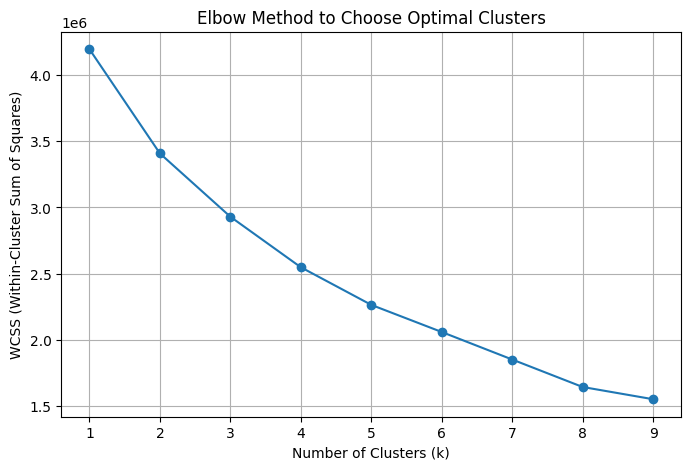

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, 10), wcss, marker='o', linestyle='-')
plt.title("Elbow Method to Choose Optimal Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS (Within-Cluster Sum of Squares)")
plt.grid(True)
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


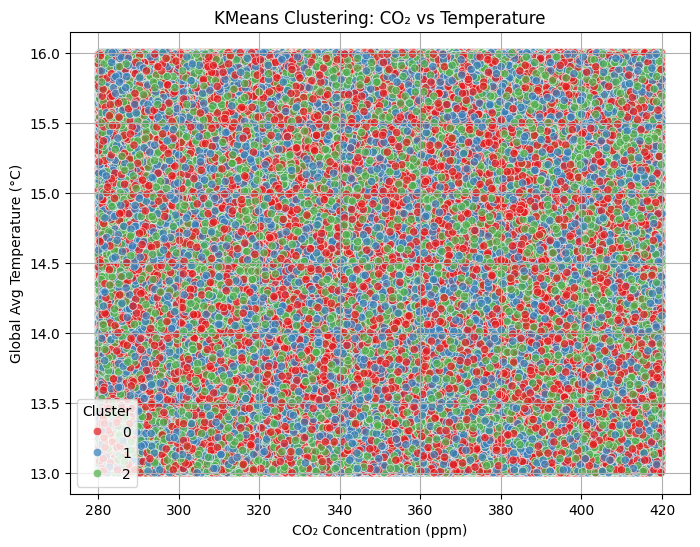

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='CO2 Concentration (ppm)', y='Global Average Temperature (°C)',
                hue='Cluster', palette='Set1', alpha=0.7)
plt.title("KMeans Clustering: CO₂ vs Temperature")
plt.xlabel("CO₂ Concentration (ppm)")
plt.ylabel("Global Avg Temperature (°C)")
plt.grid(True)
plt.legend(title='Cluster')
plt.show()

In [ ]:
cluster_summary = df.groupby('Cluster')[features].mean()
print("\n📊 Average Feature Values in Each Cluster:\n")
print(cluster_summary)




📊 Average Feature Values in Each Cluster:

         Global Average Temperature (°C)  CO2 Concentration (ppm)  \
Cluster                                                             
0                              14.501037               349.922990   
1                              14.505726               350.380370   
2                              14.491550               349.801953   

         Sea Level Rise (mm)  Arctic Ice Area (million km²)  
Cluster                                                      
0                 149.982471                       5.355493  
1                 230.466139                      11.196184  
2                  69.539139                      11.186896  


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048576 entries, 0 to 1048575
Data columns (total 6 columns):
 #   Column                           Non-Null Count    Dtype  
---  ------                           --------------    -----  
 0   Year                             1048576 non-null  int64  
 1   Global Average Temperature (°C)  1048576 non-null  float64
 2   CO2 Concentration (ppm)          1048576 non-null  float64
 3   Sea Level Rise (mm)              1048576 non-null  float64
 4   Arctic Ice Area (million km²)    1048576 non-null  float64
 5   Cluster                          1048576 non-null  int32  
dtypes: float64(4), int32(1), int64(1)
memory usage: 44.0 MB
None
               Year  Global Average Temperature (°C)  CO2 Concentration (ppm)  \
count  1.048576e+06                     1.048576e+06             1.048576e+06   
mean   1.961505e+03                     1.449954e+01             3.500280e+02   
std    3.579736e+01                     8.661005e-01             4.

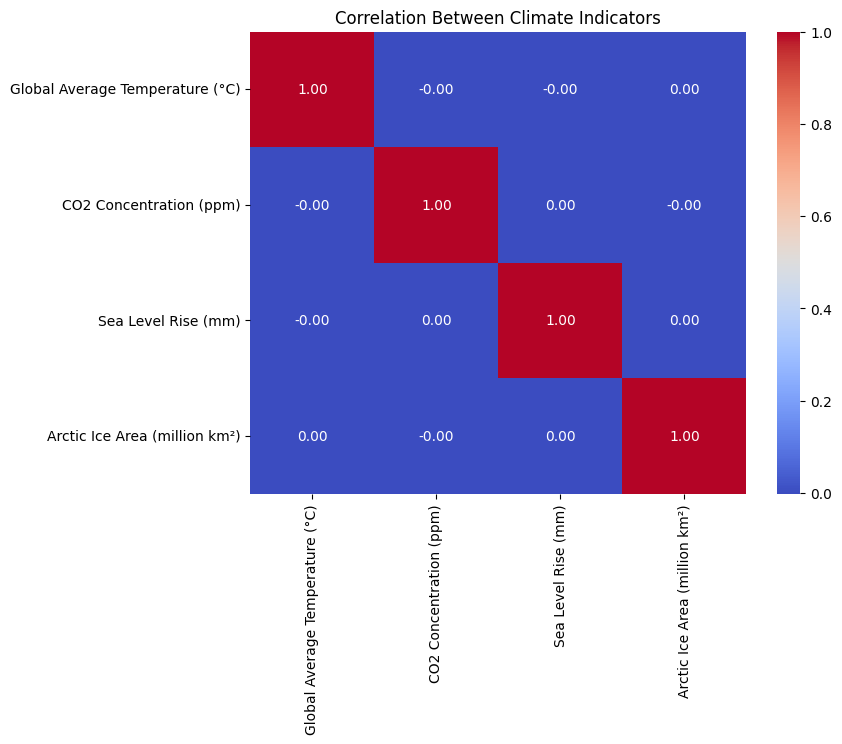

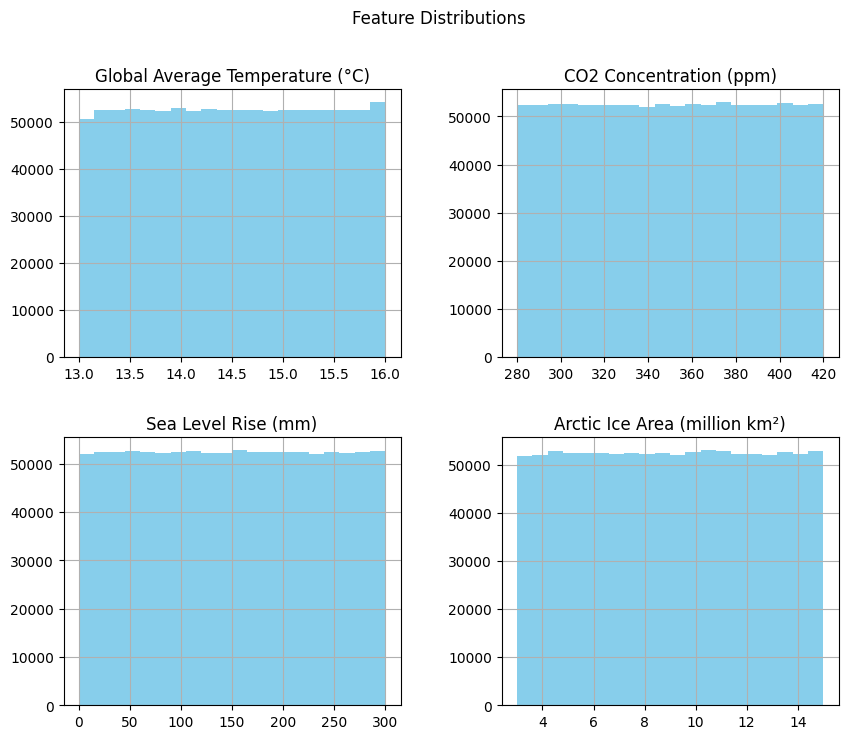

In [ ]:
# --- Basic info ---
print(df.info())
print(df.describe())
print("\nMissing values per column:\n", df.isnull().sum())

# --- Correlation Heatmap ---
features = ['Global Average Temperature (°C)', 'CO2 Concentration (ppm)',
            'Sea Level Rise (mm)', 'Arctic Ice Area (million km²)']
plt.figure(figsize=(8,6))
sns.heatmap(df[features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Between Climate Indicators")
plt.show()

# --- Feature Distributions ---
df[features].hist(figsize=(10,8), bins=20, color='skyblue')
plt.suptitle("Feature Distributions")
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import silhouette_score

# Use only 1000 random samples (or less if data is smaller)
sample_idx = np.random.choice(len(X_scaled), size=min(1000, len(X_scaled)), replace=False)
X_sample = X_scaled[sample_idx]

for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_sample)
    score = silhouette_score(X_sample, labels)
    print(f"k={k} → silhouette score = {score:.3f}")

k=2 → silhouette score = 0.193
k=3 → silhouette score = 0.181
k=4 → silhouette score = 0.195
k=5 → silhouette score = 0.207
k=6 → silhouette score = 0.206


In [ ]:
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)


In [ ]:
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import numpy as np

# Use a sample of the data for faster silhouette score calculation
sample_size = 1000
if len(X_scaled) > sample_size:
    sample_indices = np.random.choice(len(X_scaled), size=sample_size, replace=False)
    X_sample = X_scaled[sample_indices]
else:
    X_sample = X_scaled


for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    # Fit KMeans on the sample for silhouette score calculation
    labels = kmeans.fit_predict(X_sample)
    score = silhouette_score(X_sample, labels)
    print(f"k={k} → silhouette score = {score:.3f}")

k=2 → silhouette score = 0.192
k=3 → silhouette score = 0.186
k=4 → silhouette score = 0.201
k=5 → silhouette score = 0.211
k=6 → silhouette score = 0.219
